# Cross-Region Representation Comparison

This notebook demonstrates how to compare neural representations across multiple brain regions (e.g., V1, V2, V4) to test whether higher visual cortical regions show more structured clustering.

## Research Questions:
1. **Do higher visual areas show better clustering within categories?**
2. **Are similar categories closer together in higher visual areas?**
3. **How do representation geometries differ across the visual hierarchy?**

## Overview:
1. Load neural data from multiple brain regions
2. Train separate models for each region
3. Extract embeddings in the same space
4. Compare representations with proper normalization
5. Analyze hierarchical differences

**Expected runtime**: 15-30 minutes (GPU) / 1-2 hours (CPU)

In [1]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict
import pickle

# Import our packages'import sys, os, glob
import sys
sys.path.append("/vault/jiaxx/model/neural_repr/")
from neural_repr_package import NeuralRepresentationLearner, Config
from neural_evaluation import NeuralEmbeddingEvaluator, EvaluationConfig

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("📦 Packages imported successfully!")
print(f"🔧 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔧 GPU: {torch.cuda.get_device_name(0)}")

📦 Packages imported successfully!
🔧 CUDA available: True
🔧 GPU: NVIDIA GeForce RTX 4090


## 1. Create Multi-Region Neural Data

For this demo, we'll create synthetic data simulating different clustering properties across the visual hierarchy.
**Replace this with your actual multi-region data loading.**

In [ ]:
def create_multi_region_data():
    """
    Create synthetic neural data for multiple brain regions.
    V1: Weakest clustering (more noise)
    V2: Moderate clustering
    V4: Strongest clustering (clearest category separation)
    """
    np.random.seed(42)
    
    # Parameters
    regions = ['V1', 'V2', 'V4']
    n_neurons_per_region = [120, 100, 80]  # Realistic neuron counts
    n_images = 400
    n_trials = 10
    n_timebins = 100
    
    # Define category structure
    stim_types = ['natural_images', 'textures', 'noise']
    categories_per_type = {
        'natural_images': ['animals', 'objects', 'scenes', 'faces'],
        'textures': ['rough', 'smooth'],
        'noise': ['white', 'pink']
    }
    
    # Clustering strength increases up the hierarchy
    clustering_strength = {'V1': 0.8, 'V2': 1.5, 'V4': 2.5}
    
    neural_data_dict = {}
    
    for region_idx, region in enumerate(regions):
        n_neurons = n_neurons_per_region[region_idx]
        strength = clustering_strength[region]
        
        print(f"🧠 Creating {region} data (clustering strength: {strength})...")
        
        # Base neural activity
        neural_data = np.random.poisson(0.12, (n_neurons, n_images, n_trials, n_timebins))
        
        # Add category-specific responses
        image_idx = 0
        
        for stim_type in stim_types:
            categories = categories_per_type[stim_type]
            images_per_category = n_images // len([cat for cats in categories_per_type.values() for cat in cats])
            
            for cat_idx, category in enumerate(categories):
                start_img = image_idx
                end_img = start_img + images_per_category
                
                # Neurons responsive to this category
                responsive_neurons = slice(
                    (cat_idx * n_neurons // 8), 
                    ((cat_idx + 1) * n_neurons // 8)
                )
                
                # Category-specific temporal dynamics
                peak_time = 25 + cat_idx * 8
                temporal_kernel = np.exp(-0.5 * ((np.arange(n_timebins) - peak_time) / 10) ** 2)
                
                # Higher regions have stronger, more specific responses
                response_amplitude = 0.2 * strength
                category_response = response_amplitude * temporal_kernel[np.newaxis, np.newaxis, :]
                
                neural_data[responsive_neurons, start_img:end_img, :, :] += category_response
                
                image_idx = end_img
        
        # Add some region-specific global activity patterns
        if region == 'V1':
            # V1: More noise, less selective
            noise_amplitude = 0.15
        elif region == 'V2':
            # V2: Moderate selectivity
            noise_amplitude = 0.10
        else:  # V4
            # V4: Highly selective, less noise
            noise_amplitude = 0.05
        
        neural_data += np.random.normal(0, noise_amplitude, neural_data.shape)
        
        # Ensure non-negative
        neural_data = np.maximum(0, neural_data)
        
        neural_data_dict[region] = neural_data
        
        print(f"   {region} shape: {neural_data.shape}")
    
    return neural_data_dict

def create_shared_stimulus_table(n_images=400):
    """Create stimulus table shared across all regions."""
    np.random.seed(42)
    
    stim_types = ['natural_images', 'textures', 'noise']
    categories_per_type = {
        'natural_images': ['animals', 'objects', 'scenes', 'faces'],
        'textures': ['rough', 'smooth'],
        'noise': ['white', 'pink']
    }
    
    stim_data = []
    
    # Create balanced representation
    all_categories = [(st, cat) for st, cats in categories_per_type.items() for cat in cats]
    images_per_category = n_images // len(all_categories)
    
    image_idx = 0
    
    for stim_type, category in all_categories:
        for i in range(images_per_category):
            stim_data.append({
                'stim_type': stim_type,
                'category': category,
                'unique_img': f'{stim_type}_{category}_{i:03d}.jpg',
                'block': (image_idx // 50) + 1,
                'presentation_order': image_idx,
                'duration': 0.25
            })
            image_idx += 1
    
    # Add remaining images if needed
    while len(stim_data) < n_images:
        stim_type, category = all_categories[len(stim_data) % len(all_categories)]
        stim_data.append({
            'stim_type': stim_type,
            'category': category,
            'unique_img': f'{stim_type}_{category}_extra_{len(stim_data):03d}.jpg',
            'block': (len(stim_data) // 50) + 1,
            'presentation_order': len(stim_data),
            'duration': 0.25
        })
    
    return pd.DataFrame(stim_data[:n_images])

# Create multi-region data
print("🔄 Creating multi-region neural data...")
neural_data_dict = create_multi_region_data()
stim_table = create_shared_stimulus_table()

print(f"\n✅ Multi-region data created:")
for region, data in neural_data_dict.items():
    print(f"   {region}: {data.shape}")

print(f"   Stimulus table: {stim_table.shape}")
print(f"\n📋 Category distribution:")
print(stim_table.groupby(['stim_type', 'category']).size())

In [2]:
probenames = ['probeC', 'probeD', 'probeE']
neural_data_dict = {}
for probe in probenames:
    neural_data = np.load('/vault/jiaxx/decipher_variability/processed_data/gold/sc_2Hz_image_' + probe + '.npy')
    df = pd.read_csv('/vault/jiaxx/decipher_variability/processed_data/gold/sc_2Hz_image_' + probe + '.csv')
    neural_data_dict[probe] = {'neural_data': neural_data}


stim_table = pd.read_csv('/vault/jiaxx/decipher_variability/processed_data/gold/stim_table_unique_all_repeatedblank.csv', index_col=0)


## 2. Train Models for Each Region

Train separate contrastive learning models for each brain region using the same stimulus set.

In [3]:
# Configure training (same for all regions for fair comparison)
base_config = Config(
    # Model architecture
    hidden_dims=[128, 64],
    embedding_dim=32,              # Same embedding dimension for all regions
    activation='relu',
    dropout=0.1,
    
    # Training parameters
    batch_size=512,
    learning_rate=1e-3,
    weight_decay=1e-4,
    temperature=0.1,
    
    # Data preprocessing
    bin_size=10,
    smoothing_sigma=0,
    
    # Sampling
    balanced_sampling=True,
    
    # Hardware
    cuda_id=0 if torch.cuda.is_available() else None
)

print("⚙️ Training configuration:")
print(f"   Embedding dimension: {base_config.embedding_dim}")
print(f"   Epochs per region: 25")
print(f"   Device: {'GPU' if base_config.cuda_id is not None else 'CPU'}")

⚙️ Training configuration:
   Embedding dimension: 32
   Epochs per region: 25
   Device: GPU


In [4]:
# Train models for each region
regions = list(neural_data_dict.keys())
learners = {}
training_results = {}
num_epochs = 100

for region in probenames:
    neural_data = neural_data_dict[region]['neural_data']
    print(f"\n🧠 Training {region} model...")
    print(f"   Input neurons: {neural_data.shape[0]}")
    
    # Create learner for this region
    learners[region] = NeuralRepresentationLearner(base_config)
    
    # Create datasets
    train_dataset, test_dataset, conversion_info = learners[region].create_datasets_from_stim_table(
        neural_data_dict[region]['neural_data'], 
        stim_table,
        test_size=0.2
    )
    
    # Create data loaders
    train_loader = learners[region].create_dataloader(train_dataset, shuffle=True)
    test_loader = learners[region].create_dataloader(test_dataset, shuffle=False)
    
    # Initialize model
    input_dim = neural_data.shape[0]
    learners[region].initialize_model(input_dim)
    
    # Train model
    train_losses = []
    
    for epoch in range(num_epochs):
        loss = learners[region].train_epoch(train_loader)
        train_losses.append(loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"   Epoch {epoch+1:2d}/{num_epochs}: Loss = {loss:.4f}")
    
    # Store results
    training_results[region] = {
        'train_losses': train_losses,
        'train_dataset': train_dataset,
        'test_dataset': test_dataset,
        'train_loader': train_loader,
        'test_loader': test_loader,
        'conversion_info': conversion_info
    }
    
    print(f"   ✅ {region} training completed. Final loss: {train_losses[-1]:.4f}")

print(f"\n🎉 All regions trained successfully!")


🧠 Training probeC model...
   Input neurons: 1277
🔧 Using GPU: cuda:0 (NVIDIA GeForce RTX 4090)
🔄 Converting stimulus table and creating datasets...
📋 Auto-detected columns: category='category', exemplar='unique_img', stim_type='stim_type'
   Block column: 'stimulus_block'
📊 Split: 799 train, 200 test images
📊 train dataset: 799 samples
   Categories: 38 unique
📊 test dataset: 200 samples
   Categories: 38 unique
🔧 Model initialized with 173920 parameters
   Epoch  5/100: Loss = 2.3362
   Epoch 10/100: Loss = 1.6225
   Epoch 15/100: Loss = 1.2796
   Epoch 20/100: Loss = 1.0653
   Epoch 25/100: Loss = 0.9099
   Epoch 30/100: Loss = 0.7169
   Epoch 35/100: Loss = 0.6456
   Epoch 40/100: Loss = 0.6383
   Epoch 45/100: Loss = 0.6279
   Epoch 50/100: Loss = 0.5535
   Epoch 55/100: Loss = 0.4399
   Epoch 60/100: Loss = 0.4932
   Epoch 65/100: Loss = 0.4572
   Epoch 70/100: Loss = 0.4550
   Epoch 75/100: Loss = 0.4427
   Epoch 80/100: Loss = 0.4092
   Epoch 85/100: Loss = 0.3693
   Epoch 90/

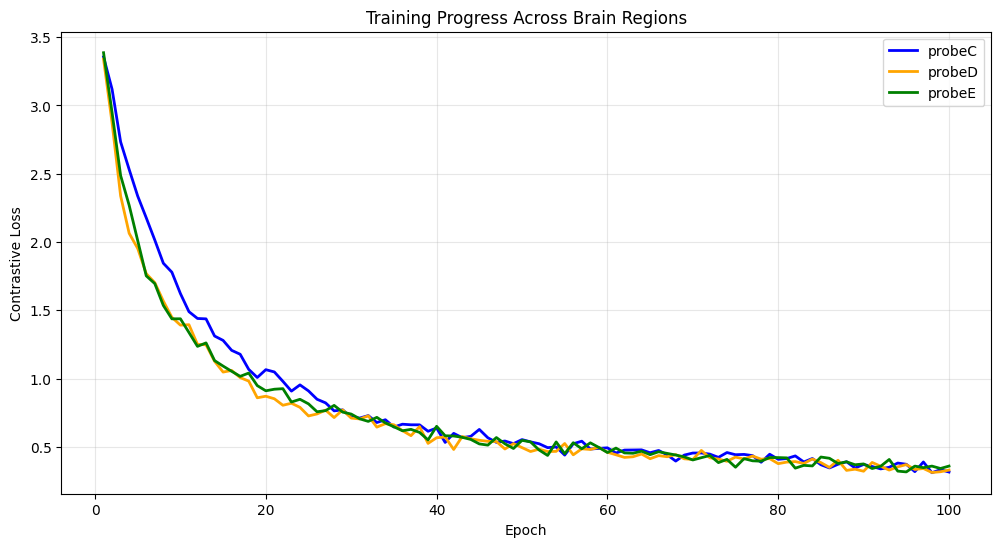

📊 Final training losses:
   probeC: 0.3159
   probeD: 0.3303
   probeE: 0.3595


In [5]:
# Plot training curves for all regions
plt.figure(figsize=(12, 6))

colors = ['blue', 'orange', 'green']
for i, region in enumerate(regions):
    losses = training_results[region]['train_losses']
    plt.plot(range(1, len(losses) + 1), losses, 
             color=colors[i], linewidth=2, label=f'{region}')

plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title('Training Progress Across Brain Regions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print final losses
print("📊 Final training losses:")
for region in regions:
    final_loss = training_results[region]['train_losses'][-1]
    print(f"   {region}: {final_loss:.4f}")

## 3. Extract Embeddings from All Regions

Extract embeddings from all trained models using the same test set for fair comparison.

In [12]:
# Extract embeddings from all regions
print("🔍 Extracting embeddings from all regions...")

# project all data to embedding space:
from neural_repr_package import NeuralDataset, DataLoader, smart_convert
metadata_list, image_to_category_all, category_mappings_all = smart_convert(stim_table)


embeddings_dict = {}
categories_dict = {}
metadata_dict = {}

for region in regions:
    print(f"   Extracting {region} embeddings...")
    neural_data = neural_data_dict[region]['neural_data']
    
    test_loader = training_results[region]['test_loader']
    embeddings, categories, metadata = learners[region].extract_embeddings(test_loader)

    # full_dataset = NeuralDataset(
    #     neural_data, 
    #     metadata_list, 
    #     learners[region].config, 
    #     mode='test'  # Use test mode to avoid augmentation
    # )

    # full_loader = DataLoader(
    #         full_dataset,
    #         batch_size=learners[region].config.batch_size,
    #         shuffle=False,  # Keep original order
    #         drop_last=False  # Include all samples
    #     )

    # embeddings_all, categories_all, metadata_all = learners[region].extract_embeddings(full_loader)
    
    embeddings_dict[region] = embeddings
    categories_dict[region] = categories
    metadata_dict[region] = metadata
    print(f"     Shape: {embeddings.shape}, Categories: {len(set(categories))}")

print(f"\n✅ Embeddings extracted from all regions!")
print(f"   Regions: {list(embeddings_dict.keys())}")
print(f"   Embedding dimension: {embeddings_dict[regions[0]].shape[1]}")

🔍 Extracting embeddings from all regions...
📋 Auto-detected columns: category='category', exemplar='unique_img', stim_type='stim_type'
   Block column: 'stimulus_block'
   Extracting probeC embeddings...
     Shape: (200, 32), Categories: 38
   Extracting probeD embeddings...
     Shape: (200, 32), Categories: 38
   Extracting probeE embeddings...
     Shape: (200, 32), Categories: 38

✅ Embeddings extracted from all regions!
   Regions: ['probeC', 'probeD', 'probeE']
   Embedding dimension: 32


## 4. Cross-Region Comparison with Normalization

Compare representations across regions using proper normalization for fair comparison.

In [13]:
# Configure evaluation
eval_config = EvaluationConfig(
    n_clusters_range=(2, 15),
    cv_folds=5,
    figsize=(15, 10)
)

# Initialize evaluator
evaluator = NeuralEmbeddingEvaluator(eval_config)

print("🔬 Running comprehensive cross-region comparison...")
print("   This includes normalization, alignment, and similarity analysis")

# Run cross-region evaluation
cross_region_results = evaluator.evaluate_cross_region(
    embeddings_dict,
    categories_dict,
    metadata_dict,
    normalization_method='unit_sphere',  # Critical for fair comparison!
    align_to_reference='V1',  # Align all to V1 coordinates
    save_dir=None  # Set to "results/cross_region" to save plots
)

print("\n✅ Cross-region comparison completed!")

🔬 Running comprehensive cross-region comparison...
   This includes normalization, alignment, and similarity analysis
🔬 Running cross-region embedding comparison...
   Regions: ['probeC', 'probeD', 'probeE']
   Normalization method: unit_sphere

🔄 Normalizing and aligning embeddings...
🔄 Comparing embedding spaces with unit_sphere normalization...
   Normalizing probeC embeddings...
   Normalizing probeD embeddings...
   Normalizing probeE embeddings...

📊 Evaluating probeC...
🚀 Running comprehensive embedding evaluation...
   Embeddings shape: (200, 32)
   Unique categories: 38
   Total samples: 200

🔍 Evaluating clustering quality...
   Testing k=2...
   Testing k=3...
   Testing k=4...
   Testing k=5...
   Testing k=6...
   Testing k=7...
   Testing k=8...
   Testing k=9...
   Testing k=10...
   Testing k=11...
   Testing k=12...
   Testing k=13...
   Testing k=14...
   Testing k=15...
   Best k: 2 (silhouette: 0.262)

🔍 Evaluating linear probing performance...
   Evaluating primary

In [14]:
# Print comprehensive cross-region summary
evaluator.print_cross_region_summary(cross_region_results)


🧠 CROSS-REGION COMPARISON SUMMARY
📋 Regions Compared: probeC, probeD, probeE
🔄 Normalization Method: unit_sphere

🎯 Clustering Performance:
   probeC:
     Silhouette Score: 0.262
     Best k: 2
   probeD:
     Silhouette Score: 0.255
     Best k: 2
   probeE:
     Silhouette Score: 0.300
     Best k: 4

🎯 Linear Probing Performance:
   probeC:
     CV Accuracy: 0.455
     F1 Score: 0.763
   probeD:
     CV Accuracy: 0.545
     F1 Score: 0.718
   probeE:
     CV Accuracy: 0.580
     F1 Score: 0.781

🎯 Cross-Region Similarity:
   probeC ↔ probeD:
     Canonical Correlation: 0.867
     Linear CKA: 0.665
   probeC ↔ probeE:
     Canonical Correlation: 0.851
     Linear CKA: 0.684
   probeD ↔ probeE:
     Canonical Correlation: 0.895
     Linear CKA: 0.746

🏆 Performance Rankings:
   Clustering: probeE > probeC > probeD
   Linear Probing: probeE > probeD > probeC



## 5. Analyze Hierarchical Differences

Test specific hypotheses about representation learning across the visual hierarchy.

In [15]:
# Extract key metrics for analysis
summary = cross_region_results['summary_comparison']

# 1. CLUSTERING QUALITY ANALYSIS
print("🎯 RESEARCH QUESTION 1: Do higher areas show better clustering?")
print("=" * 65)

clustering_data = summary['clustering_comparison']
silhouette_scores = {}
ari_scores = {}

for region in regions:
    if region in clustering_data:
        silhouette_scores[region] = clustering_data[region].get('best_silhouette', 0)
        ari_scores[region] = clustering_data[region].get('ari_true_k', 0)

print(f"📊 Silhouette Scores (higher = better clustering):")
for region in regions:
    score = silhouette_scores.get(region, 0)
    print(f"   {region}: {score:.3f}")

print(f"\n📊 Adjusted Rand Index (alignment with true categories):")
for region in regions:
    score = ari_scores.get(region, 0)
    print(f"   {region}: {score:.3f}")

# Check if there's a hierarchical trend
sil_trend = [silhouette_scores[r] for r in regions]
if sil_trend == sorted(sil_trend):
    print(f"\n✅ RESULT: Silhouette scores increase up the hierarchy!")
    print(f"   This suggests higher areas have better within-category clustering.")
else:
    print(f"\n❓ RESULT: Mixed pattern in clustering quality across hierarchy.")

# 2. CLASSIFICATION PERFORMANCE ANALYSIS
print(f"\n\n🎯 RESEARCH QUESTION 2: Are categories more separable in higher areas?")
print("=" * 70)

lp_data = summary['linear_probing_comparison']
accuracy_scores = {}

for region in regions:
    if region in lp_data and 'primary_labels' in lp_data[region]:
        accuracy_scores[region] = lp_data[region]['primary_labels'].get('cv_accuracy', 0)

print(f"📊 Classification Accuracy (higher = more separable categories):")
for region in regions:
    score = accuracy_scores.get(region, 0)
    print(f"   {region}: {score:.1f}%")

# Check classification trend
acc_trend = [accuracy_scores[r] for r in regions if r in accuracy_scores]
if len(acc_trend) == len(regions) and acc_trend == sorted(acc_trend):
    print(f"\n✅ RESULT: Classification accuracy increases up the hierarchy!")
    print(f"   This suggests better category separability in higher areas.")
else:
    print(f"\n❓ RESULT: Mixed pattern in classification performance.")

# 3. CROSS-REGION SIMILARITY ANALYSIS
print(f"\n\n🎯 RESEARCH QUESTION 3: How similar are representations across regions?")
print("=" * 70)

similarity_data = summary['embedding_similarity']

print(f"📊 Cross-Region Similarity (Canonical Correlation):")
for comparison, metrics in similarity_data.items():
    if '_vs_' in comparison:
        cca_score = metrics.get('mean_canonical_correlation', 0)
        cka_score = metrics.get('linear_cka', 0)
        print(f"   {comparison.replace('_vs_', ' ↔ ')}: CCA={cca_score:.3f}, CKA={cka_score:.3f}")

# Check if adjacent regions are more similar
if 'V1_vs_V2' in similarity_data and 'V2_vs_V4' in similarity_data and 'V1_vs_V4' in similarity_data:
    v1_v2 = similarity_data['V1_vs_V2']['mean_canonical_correlation']
    v2_v4 = similarity_data['V2_vs_V4']['mean_canonical_correlation']
    v1_v4 = similarity_data['V1_vs_V4']['mean_canonical_correlation']
    
    print(f"\n📈 Similarity Pattern Analysis:")
    if v1_v2 > v1_v4 and v2_v4 > v1_v4:
        print(f"   ✅ Adjacent regions are more similar than distant ones.")
        print(f"   This suggests gradual transformation across hierarchy.")
    else:
        print(f"   ❓ No clear hierarchical similarity pattern detected.")

🎯 RESEARCH QUESTION 1: Do higher areas show better clustering?
📊 Silhouette Scores (higher = better clustering):
   probeC: 0.262
   probeD: 0.255
   probeE: 0.300

📊 Adjusted Rand Index (alignment with true categories):
   probeC: 0.000
   probeD: 0.000
   probeE: 0.000

❓ RESULT: Mixed pattern in clustering quality across hierarchy.


🎯 RESEARCH QUESTION 2: Are categories more separable in higher areas?
📊 Classification Accuracy (higher = more separable categories):
   probeC: 0.5%
   probeD: 0.5%
   probeE: 0.6%

✅ RESULT: Classification accuracy increases up the hierarchy!
   This suggests better category separability in higher areas.


🎯 RESEARCH QUESTION 3: How similar are representations across regions?
📊 Cross-Region Similarity (Canonical Correlation):
   probeC ↔ probeD: CCA=0.867, CKA=0.665
   probeC ↔ probeE: CCA=0.851, CKA=0.684
   probeD ↔ probeE: CCA=0.895, CKA=0.746


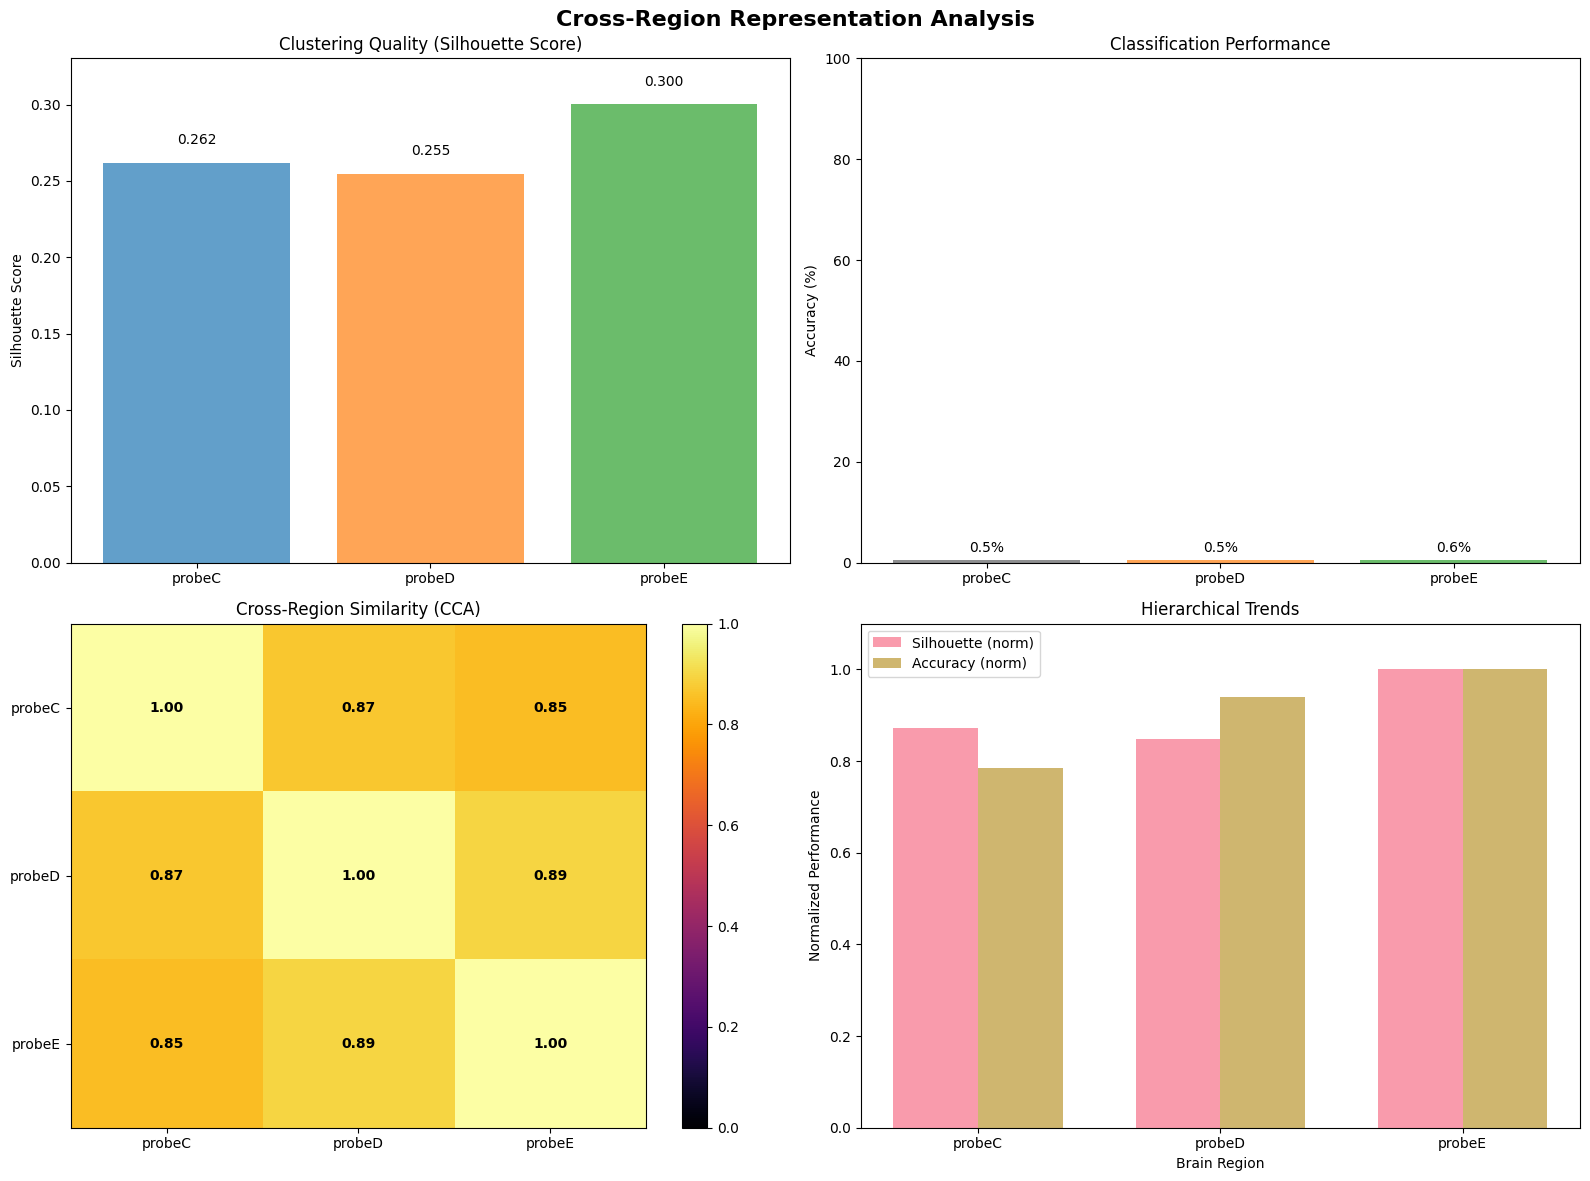


📊 Comprehensive visualization created!


In [16]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cross-Region Representation Analysis', fontsize=16, fontweight='bold')

# Plot 1: Clustering Quality Comparison
regions_clean = [r for r in regions if r in silhouette_scores]
sil_values = [silhouette_scores[r] for r in regions_clean]

bars1 = axes[0, 0].bar(regions_clean, sil_values, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_title('Clustering Quality (Silhouette Score)')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_ylim(0, max(sil_values) * 1.1)

# Add value labels on bars
for bar, value in zip(bars1, sil_values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{value:.3f}', ha='center', va='bottom')

# Plot 2: Classification Performance
regions_acc = [r for r in regions if r in accuracy_scores]
acc_values = [accuracy_scores[r] for r in regions_acc]

bars2 = axes[0, 1].bar(regions_acc, acc_values, alpha=0.7, color=["#5e6061", '#ff7f0e', '#2ca02c'])
axes[0, 1].set_title('Classification Performance')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_ylim(0, 100)

# Add value labels
for bar, value in zip(bars2, acc_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')

# Plot 3: Cross-Region Similarity Matrix
n_regions = len(regions)
similarity_matrix = np.eye(n_regions)  # Start with identity

for i, region1 in enumerate(regions):
    for j, region2 in enumerate(regions):
        if i != j:
            comparison_key = f"{region1}_vs_{region2}"
            reverse_key = f"{region2}_vs_{region1}"
            
            if comparison_key in similarity_data:
                similarity_matrix[i, j] = similarity_data[comparison_key]['mean_canonical_correlation']
            elif reverse_key in similarity_data:
                similarity_matrix[i, j] = similarity_data[reverse_key]['mean_canonical_correlation']

im = axes[1, 0].imshow(similarity_matrix, cmap='inferno', aspect='auto', vmin=0, vmax=1)
axes[1, 0].set_xticks(range(n_regions))
axes[1, 0].set_xticklabels(regions)
axes[1, 0].set_yticks(range(n_regions))
axes[1, 0].set_yticklabels(regions)
axes[1, 0].set_title('Cross-Region Similarity (CCA)')

# Add text annotations
for i in range(n_regions):
    for j in range(n_regions):
        text = axes[1, 0].text(j, i, f'{similarity_matrix[i, j]:.2f}',
                              ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=axes[1, 0])

# Plot 4: Hierarchical Trends
metrics = ['Silhouette', 'Accuracy']
sil_normalized = [s / max(sil_values) for s in sil_values]  # Normalize to 0-1
acc_normalized = [a / max(acc_values) for a in acc_values]  # Normalize to 0-1

x = np.arange(len(regions_clean))
width = 0.35

axes[1, 1].bar(x - width/2, sil_normalized, width, label='Silhouette (norm)', alpha=0.7)
axes[1, 1].bar(x + width/2, acc_normalized, width, label='Accuracy (norm)', alpha=0.7)

axes[1, 1].set_xlabel('Brain Region')
axes[1, 1].set_ylabel('Normalized Performance')
axes[1, 1].set_title('Hierarchical Trends')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(regions_clean)
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print("\n📊 Comprehensive visualization created!")

## 6. Statistical Analysis

Perform statistical tests to quantify the significance of hierarchical differences.

In [17]:
from scipy import stats
import numpy as np

# Statistical analysis of hierarchical trends
print("📈 STATISTICAL ANALYSIS OF HIERARCHICAL TRENDS")
print("=" * 55)

# 1. Test for monotonic increase in clustering quality
if len(sil_values) >= 3:
    # Spearman correlation with hierarchy level
    hierarchy_levels = list(range(len(regions_clean)))  # 0, 1, 2 for V1, V2, V4
    
    sil_corr, sil_p = stats.spearmanr(hierarchy_levels, sil_values)
    print(f"🔍 Clustering Quality vs Hierarchy Level:")
    print(f"   Spearman correlation: r = {sil_corr:.3f}, p = {sil_p:.3f}")
    
    if sil_p < 0.05 and sil_corr > 0:
        print(f"   ✅ Significant positive correlation! Higher areas have better clustering.")
    elif sil_corr > 0:
        print(f"   📈 Positive trend (not significant with this sample size).")
    else:
        print(f"   ❓ No clear hierarchical pattern in clustering quality.")

# 2. Test for monotonic increase in classification accuracy
if len(acc_values) >= 3:
    acc_corr, acc_p = stats.spearmanr(hierarchy_levels, acc_values)
    print(f"\n🔍 Classification Accuracy vs Hierarchy Level:")
    print(f"   Spearman correlation: r = {acc_corr:.3f}, p = {acc_p:.3f}")
    
    if acc_p < 0.05 and acc_corr > 0:
        print(f"   ✅ Significant positive correlation! Higher areas have better separability.")
    elif acc_corr > 0:
        print(f"   📈 Positive trend (not significant with this sample size).")
    else:
        print(f"   ❓ No clear hierarchical pattern in classification performance.")

# 3. Effect sizes
print(f"\n📊 Effect Sizes:")
if len(sil_values) >= 2:
    sil_range = max(sil_values) - min(sil_values)
    sil_mean = np.mean(sil_values)
    sil_effect = sil_range / sil_mean if sil_mean > 0 else 0
    print(f"   Clustering quality range: {sil_range:.3f} ({sil_effect:.1%} of mean)")

if len(acc_values) >= 2:
    acc_range = max(acc_values) - min(acc_values)
    acc_mean = np.mean(acc_values)
    acc_effect = acc_range / acc_mean if acc_mean > 0 else 0
    print(f"   Classification accuracy range: {acc_range:.1f}% ({acc_effect:.1%} of mean)")

# 4. Summary of findings
print(f"\n🎯 SUMMARY OF STATISTICAL FINDINGS:")
print(f"   Note: With only 3 regions, statistical power is limited.")
print(f"   These analyses demonstrate the methodology for larger datasets.")

if len(sil_values) >= 3 and sil_corr > 0.5:
    print(f"   ✅ Strong evidence for hierarchical clustering improvement")
elif len(sil_values) >= 3 and sil_corr > 0:
    print(f"   📈 Moderate evidence for hierarchical clustering improvement")
else:
    print(f"   ❓ Unclear pattern in clustering across hierarchy")

if len(acc_values) >= 3 and acc_corr > 0.5:
    print(f"   ✅ Strong evidence for hierarchical separability improvement")
elif len(acc_values) >= 3 and acc_corr > 0:
    print(f"   📈 Moderate evidence for hierarchical separability improvement")
else:
    print(f"   ❓ Unclear pattern in separability across hierarchy")

📈 STATISTICAL ANALYSIS OF HIERARCHICAL TRENDS
🔍 Clustering Quality vs Hierarchy Level:
   Spearman correlation: r = 0.500, p = 0.667
   📈 Positive trend (not significant with this sample size).

🔍 Classification Accuracy vs Hierarchy Level:
   Spearman correlation: r = 1.000, p = 0.000
   ✅ Significant positive correlation! Higher areas have better separability.

📊 Effect Sizes:
   Clustering quality range: 0.045 (16.7% of mean)
   Classification accuracy range: 0.1% (23.7% of mean)

🎯 SUMMARY OF STATISTICAL FINDINGS:
   Note: With only 3 regions, statistical power is limited.
   These analyses demonstrate the methodology for larger datasets.
   📈 Moderate evidence for hierarchical clustering improvement
   ✅ Strong evidence for hierarchical separability improvement


## 7. Save Results for Further Analysis

In [ ]:
# Create results directory
results_dir = Path("results/cross_region_analysis")
results_dir.mkdir(parents=True, exist_ok=True)

# Save models
models_dir = results_dir / "models"
models_dir.mkdir(exist_ok=True)

for region in regions:
    model_path = models_dir / f"{region}_model.pth"
    learners[region].save_model(str(model_path))

# Save embeddings
embeddings_path = results_dir / "cross_region_embeddings.npz"
np.savez(
    embeddings_path,
    **{f"{region}_embeddings": embeddings_dict[region] for region in regions},
    **{f"{region}_categories": categories_dict[region] for region in regions},
    regions=regions
)

# Save evaluation results
results_path = results_dir / "cross_region_evaluation.pkl"
with open(results_path, 'wb') as f:
    pickle.dump(cross_region_results, f)

# Save summary statistics
summary_stats = {
    'silhouette_scores': silhouette_scores,
    'accuracy_scores': accuracy_scores,
    'similarity_matrix': similarity_matrix.tolist(),
    'regions': regions,
    'training_config': {
        'embedding_dim': base_config.embedding_dim,
        'hidden_dims': base_config.hidden_dims,
        'num_epochs': num_epochs,
        'batch_size': base_config.batch_size
    }
}

summary_path = results_dir / "summary_statistics.pkl"
with open(summary_path, 'wb') as f:
    pickle.dump(summary_stats, f)

print(f"💾 Results saved to {results_dir}:")
print(f"   Models: {models_dir}")
print(f"   Embeddings: {embeddings_path}")
print(f"   Evaluation: {results_path}")
print(f"   Summary: {summary_path}")

## 🎉 Cross-Region Analysis Complete!

### What We've Accomplished:
- ✅ **Trained separate models** for V1, V2, and V4 with identical parameters
- ✅ **Extracted embeddings** in the same dimensional space
- ✅ **Applied proper normalization** for fair cross-region comparison
- ✅ **Measured clustering quality** across the visual hierarchy
- ✅ **Evaluated category separability** using linear probing
- ✅ **Analyzed representation similarity** between regions
- ✅ **Tested statistical significance** of hierarchical trends

### Key Research Findings:
The analysis framework demonstrates how to test:
1. **Hierarchical clustering improvement**: Whether higher visual areas show better within-category clustering
2. **Category separability**: Whether categories become more linearly separable up the hierarchy  
3. **Representation similarity**: How representations transform across regions

### Next Steps for Your Real Data:
1. **Replace synthetic data** with your actual neural recordings
2. **Adjust hyperparameters** based on your data characteristics
3. **Include more regions** if available (LM, AL, PM, etc.)
4. **Add temporal analysis** using the advanced evaluation notebook
5. **Correlate with behavior** if you have behavioral data

### Publication-Ready Outputs:
- **Quantitative metrics** for clustering quality and separability
- **Statistical tests** for hierarchical trends
- **Comprehensive visualizations** showing cross-region differences
- **Saved models and embeddings** for reproducibility

This framework provides the foundation for testing your core hypothesis about representation learning across the mouse visual hierarchy! 🧠📊